In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch

from botorch.utils.multi_objective.pareto import is_non_dominated
from botorch.utils.multi_objective.box_decompositions.non_dominated import FastNondominatedPartitioning

from sklearn.preprocessing import MinMaxScaler


/Users/danemerson/anaconda3/envs/py31/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
tkwargs = {
    "dtype": torch.double,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}

BATCH_SIZE = 10
ACQUISITION_FUNCTIONS = [
    "Random",
    "LogNParEGO",
    "LogNEHVI",
    "VarLogNEHVI"
]

REFERENCE = torch.tensor([0.0, 0.0], **tkwargs)

def load_all_data(data_path):
    data = torch.load(os.path.join(data_path, 'reduced_data_k100.pt')).to(**tkwargs)
    for acq in ACQUISITION_FUNCTIONS:
        for file in os.listdir(os.path.join(data_path, acq)):
            iter_data = torch.load(os.path.join(data_path, acq, file), map_location=tkwargs['device']).to(**tkwargs)
            data = torch.cat((data, iter_data), dim=0)
    return data

def load_data(data_path, acq_name):
    # Load all of the iteration data
    data = torch.load(os.path.join(data_path, 'reduced_data_k100.pt')).to(**tkwargs)
    data_path = 'data'
    for file in os.listdir(os.path.join(data_path, acq_name)):
        iter_data = torch.load(os.path.join(data_path, acq_name, file), map_location=tkwargs['device']).to(**tkwargs)
        # Append each iteration to the data tensor
        data = torch.cat((data, iter_data), dim=0)

    return data

def get_pareto_front(data, hv = False, scaler = None):
    # Scale the data if a scaler is provided
    if scaler is not None:
        data = torch.Tensor(scaler.transform(data.numpy()))
    # Use FastNondominatedPartitioning to get the pareto front and hv if needed
    partitioning = FastNondominatedPartitioning(ref_point=REFERENCE, Y=data)
    pareto_front = partitioning.pareto_Y
    if hv:
        return pareto_front, partitioning.compute_hypervolume()
    else:
        return pareto_front

def get_igd(test_front, reference_front, p=2):
    dists = torch.cdist(reference_front, test_front, p=p)
    return dists.min(dim=1).values.mean()

def plotter(igd = True):
    # Load all data
    all_data = load_all_data('data')

    # Suppose all_points is your (N, M) tensor
    scaler = MinMaxScaler()     # scales each column to [0,1]
    scaler.fit(all_data[:,-3:-1].numpy())

    # Get the reference pareto front
    reference_front = get_pareto_front(all_data[:,-3:-1], scaler = scaler)

    # Plot settings
    fig, ax1 = plt.subplots()
    if igd:
        ax2 = ax1.twinx()

    # Loop through each acq function
    for acq in ACQUISITION_FUNCTIONS:
        acq_data = load_data('data', acq)
        hv_values = []
        if igd:
            igd_values = []
        # Loop through each iteration
        for i in range(8+1):
            # Load the initial 100 points plus the points up to the ith iteration
            iter_data = acq_data[:(100+(BATCH_SIZE*(i))),-3:-1]
            # Compute the pareto front and hv
            iter_pareto_front, iter_hv = get_pareto_front(iter_data, hv = True, scaler = scaler)
            # Compute the IGD between the iteration pareto front and the reference front
            igd_value = get_igd(iter_pareto_front, reference_front)
            # Append the values
            hv_values.append(iter_hv.item())
            if igd:
                igd_values.append(igd_value.item())
        # Plot the hv and igd values
        ax1.plot(range(0, (8+1)), hv_values, label=f'HV - {acq}', linestyle='-', marker = 'o')
        if igd:
            ax2.plot(range(0, (8+1)), igd_values, label=f'IGD - {acq}', linestyle='--', marker = '.')

    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Normalized Hypervolume')
    if igd:
        ax2.set_ylabel('Inverted Generational Distance')

    # Combine legends from both axes into a single legend
    handles1, labels1 = ax1.get_legend_handles_labels()
    if igd:
        handles2, labels2 = ax2.get_legend_handles_labels()
        handles = handles1 + handles2
        labels = labels1 + labels2
        # place the combined legend to the right of the plot
        ax1.legend(handles, labels, ncol = 2, bbox_to_anchor=(0.85, -0.15))
    else:
        ax1.legend(handles1, labels1, loc='upper left')

    ax1.grid()
    # if igd:
    #     ax2.grid(which='major', axis='y', linestyle='--')
    plt.show()      

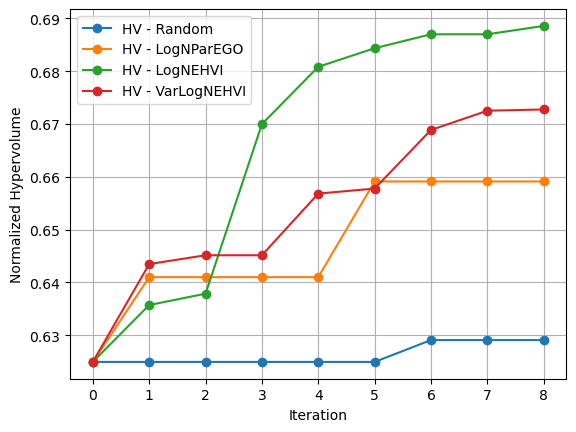

In [4]:
plotter(igd = False)

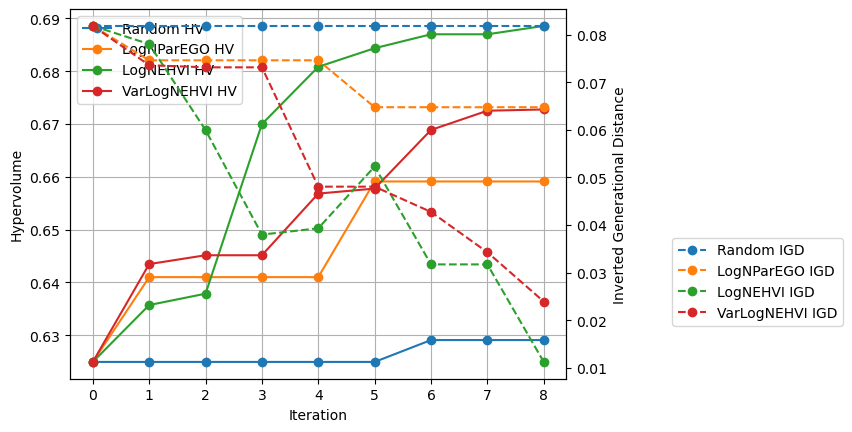

In [5]:
igd = True
# Load all data
all_data = load_all_data('data')

# Suppose all_points is your (N, M) tensor
scaler = MinMaxScaler()     # scales each column to [0,1]
scaler.fit(all_data[:,-3:-1].numpy())

# Get the reference pareto front
reference_front = get_pareto_front(all_data[:,-3:-1], scaler = scaler)

# Plot settings
fig, ax1 = plt.subplots()
if igd:
    ax2 = ax1.twinx()

# Loop through each acq function
for acq in ACQUISITION_FUNCTIONS:
    acq_data = load_data('data', acq)
    hv_values = []
    if igd:
        igd_values = []
    # Loop through each iteration
    for i in range(8+1):
        # Load the initial 100 points plus the points up to the ith iteration
        iter_data = acq_data[:(100+(BATCH_SIZE*(i))),-3:-1]
        # Compute the pareto front and hv
        iter_pareto_front, iter_hv = get_pareto_front(iter_data, hv = True, scaler = scaler)
        # Compute the IGD between the iteration pareto front and the reference front
        igd_value = get_igd(iter_pareto_front, reference_front)
        # Append the values
        hv_values.append(iter_hv.item())
        if igd:
            igd_values.append(igd_value.item())
    # Plot the hv and igd values
    ax1.plot(range(0, (8+1)), hv_values, label=f'{acq} HV', linestyle='-', marker = 'o')
    if igd:
        ax2.plot(range(0, (8+1)), igd_values, label=f'{acq} IGD', linestyle='--', marker = 'o')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Hypervolume')
ax1.legend(loc='upper left')
if igd:
    ax2.set_ylabel('Inverted Generational Distance')
    ax2.legend(bbox_to_anchor=(1.2, 0.4))
ax1.grid()
plt.show()

In [6]:
all_data = load_all_data('data')

# Suppose all_points is your (N, M) tensor
scaler = MinMaxScaler()     # scales each column to [0,1]
scaler.fit(all_data[:,-3:-1].numpy())

# Get the reference pareto front
reference_front = get_pareto_front(all_data[:,-3:-1], scaler = scaler)

# Loop through each acq function
for acq in ACQUISITION_FUNCTIONS:
    acq_data = load_data('data', acq)
    for i in range(8):
        iter_data = acq_data[:(100+(BATCH_SIZE*(i+1))),-3:-1]
        iter_pareto_front, iter_hv = get_pareto_front(iter_data, hv = True, scaler = scaler)
        igd_value = get_igd(iter_pareto_front, reference_front)
        print(f'Acquisition: {acq}, Iteration: {i}, HV: {iter_hv.item()}, IGD: {igd_value.item()}')

Acquisition: Random, Iteration: 0, HV: 0.6249410713011635, IGD: 0.0818401500582695
Acquisition: Random, Iteration: 1, HV: 0.6249410713011635, IGD: 0.0818401500582695
Acquisition: Random, Iteration: 2, HV: 0.6249410713011635, IGD: 0.0818401500582695
Acquisition: Random, Iteration: 3, HV: 0.6249410713011635, IGD: 0.0818401500582695
Acquisition: Random, Iteration: 4, HV: 0.6249410713011635, IGD: 0.0818401500582695
Acquisition: Random, Iteration: 5, HV: 0.6290799937697124, IGD: 0.0818401500582695
Acquisition: Random, Iteration: 6, HV: 0.6290799937697124, IGD: 0.0818401500582695
Acquisition: Random, Iteration: 7, HV: 0.6290799937697124, IGD: 0.0818401500582695
Acquisition: LogNParEGO, Iteration: 0, HV: 0.6409960159162417, IGD: 0.07461357116699219
Acquisition: LogNParEGO, Iteration: 1, HV: 0.6409960159162417, IGD: 0.07461357116699219
Acquisition: LogNParEGO, Iteration: 2, HV: 0.6409960159162417, IGD: 0.07461357116699219
Acquisition: LogNParEGO, Iteration: 3, HV: 0.6409960159162417, IGD: 0.07

In [7]:
HV = np.array([0.629, 0.659, 0.689, 0.673])
IGD = np.array([0.0818, 0.0648, 0.0112, 0.0239])

In [8]:
# Standard calculation for maximization
def percent_change_hv(arr, idx):
    return (arr - arr[idx])/arr[idx]*100

# Reverse the numerator since this is minimization
def percent_change_igd(arr, idx):
    return (arr[idx] - arr)/arr[idx]*100

In [9]:
print(percent_change_hv(HV, 0))
print(percent_change_hv(HV, 1))
print(percent_change_igd(IGD, 0))
print(percent_change_igd(IGD, 1))

[0.         4.76947536 9.53895072 6.99523052]
[-4.55235205  0.          4.55235205  2.12443096]
[ 0.         20.78239609 86.30806846 70.78239609]
[-26.2345679    0.          82.71604938  63.11728395]


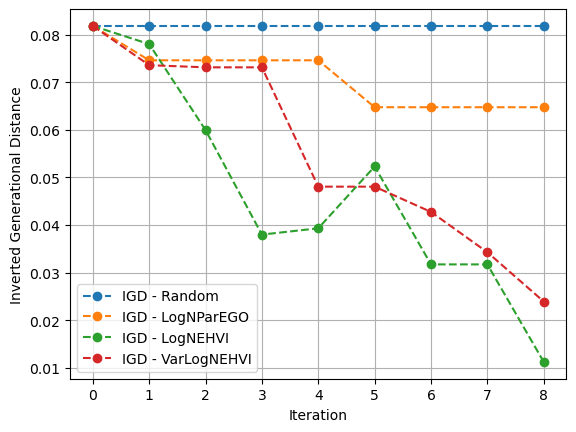

In [10]:
# Plot IGD only (separate figure)
fig, ax = plt.subplots()

# Prepare scaler and reference front
all_data = load_all_data('data')
scaler = MinMaxScaler()
scaler.fit(all_data[:,-3:-1].numpy())
reference_front = get_pareto_front(all_data[:,-3:-1], scaler=scaler)

for acq in ACQUISITION_FUNCTIONS:
    acq_data = load_data('data', acq)
    igd_values = []
    for i in range(8 + 1):
        iter_data = acq_data[:(100 + (BATCH_SIZE * i)),-3:-1]
        iter_pareto_front, _ = get_pareto_front(iter_data, hv=True, scaler=scaler)
        igd_value = get_igd(iter_pareto_front, reference_front)
        igd_values.append(igd_value.item())
    ax.plot(range(0, 8 + 1), igd_values, label=f'IGD - {acq}', linestyle='--', marker='o')

ax.set_xlabel('Iteration')
ax.set_ylabel('Inverted Generational Distance')
ax.legend(loc='lower left')
ax.grid()
plt.show()